# Group 2: Luca Milani, Marta Laskowska, Monika Kaczorowska

### Libraries

In [199]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import requests
import bs4 as bs
import yfinance as yf
import datetime
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, recall_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, brier_score_loss, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier


pd.set_option("display.max_colwidth", None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

### Web-scraping

In [164]:
url = 'http://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
                  'AppleWebKit/537.36 (KHTML, like Gecko) '
                  'Chrome/111.0.0.0 Safari/537.36'
}

resp = requests.get(url, headers=headers) 
soup = bs.BeautifulSoup(resp.text, 'lxml')

table = soup.find('table', {'id': 'constituents'})
tickers = []

for row in table.find_all('tr')[1:]:  
    cols = row.find_all('td')
    if cols:  
        ticker = cols[0].text.strip()
        tickers.append(ticker)

print(len(tickers))  
print(f'Examplary tickers scrapped: {tickers[:10]}')

503
Examplary tickers scrapped: ['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A']


In [165]:
type(tickers)

list

In [166]:
### List of tickers as input in the yfinance package (an API that gives access to Yahoo Finance data)
tickers = [s.replace('.','-') for s in tickers] + ['^SPX']
start = datetime.datetime(2010, 1, 1)
end = datetime.datetime(2020, 12, 31)
data = yf.download(tickers, start=start, end=None)
data.head()

C:\Users\lasko\AppData\Local\Temp\ipykernel_41732\2162137305.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start, end=None)
[*********************100%***********************]  504 of 504 completed


Price           Close                                                      \
Ticker              A      AAPL ABBV ABNB        ABT      ACGL        ACN   
Date                                                                        
2010-01-04  19.891674  6.424604  NaN  NaN  18.496672  7.601905  31.492178   
2010-01-05  19.675606  6.435714  NaN  NaN  18.347233  7.576549  31.686798   
2010-01-06  19.605696  6.333344  NaN  NaN  18.449120  7.543795  32.023651   
2010-01-07  19.580271  6.321636  NaN  NaN  18.601957  7.499420  31.993721   
2010-01-08  19.573923  6.363663  NaN  NaN  18.697054  7.484628  31.866455   

Price                                                                         \
Ticker           ADBE        ADI        ADM        ADP       ADSK        AEE   
Date                                                                           
2010-01-04  37.090000  21.975166  20.614491  25.898792  25.670000  15.615405   
2010-01-05  37.700001  21.940479  20.725849  25.759718  25.280001  15.553528   
2010-01-06  37.619999  21.898842  20.673450  25.699247  25.340000  15.446656   
2010-01-07  36.889999  21.725376  20.457285  25.687155  25.480000  15.300401   
2010-01-08  36.689999  21.850267  20.201813  25.650866  26.260000  15.193523   

Price                                                                        \
Ticker            AEP       AES        AFL        AIG        AIZ        AJG   
Date                                                                          
2010-01-04  19.011017  8.940193  16.221985  18.885639  22.143974  15.014436   
2010-01-05  18.793377  8.848635  16.692589  18.531813  22.804768  14.933750   
2010-01-06  18.983810  8.757077  16.839226  18.411760  22.738689  14.940472   
2010-01-07  19.147041  8.763616  17.019953  18.057928  23.017689  14.846339   
2010-01-08  19.375566  9.012136  16.849449  18.538128  23.032379  14.886682   

Price                                                                          \
Ticker           AKAM        ALB   ALGN        ALL ALLE       AMAT AMCR   AMD   
Date                                                                            
2010-01-04  25.920000  30.328411  18.50  21.307913  NaN  11.048757  NaN  9.70   
2010-01-05  26.690001  30.272696  18.01  21.658249  NaN  10.963763  NaN  9.71   
2010-01-06  26.469999  30.328411  17.48  21.665266  NaN  10.940585  NaN  9.57   
2010-01-07  26.480000  30.113428  17.43  21.777376  NaN  10.824688  NaN  9.47   
2010-01-08  26.480000  30.567299  17.66  21.868462  NaN  11.241919  NaN  9.43   

Price                                                                \
Ticker            AME       AMGN        AMP        AMT    AMZN ANET   
Date                                                                  
2010-01-04  15.491834  39.592064  28.590210  32.086201  6.6950  NaN   
2010-01-05  15.423606  39.249100  29.256927  32.617779  6.7345  NaN   
2010-01-06  15.439661  38.954147  29.665583  32.787598  6.6125  NaN   
2010-01-07  15.479789  38.597469  29.887810  32.698978  6.5000  NaN   
2010-01-08  15.780791  38.940422  29.995354  32.765450  6.6760  NaN   

Price                                                                         \
Ticker            AON       AOS        APA        APD       APH APO APP APTV   
Date                                                                           
2010-01-04  32.125507  5.849099  78.900406  51.808659  5.049890 NaN NaN  NaN   
2010-01-05  31.922300  5.774361  79.831963  51.378773  4.944364 NaN NaN  NaN   
2010-01-06  31.913828  5.776984  81.084007  50.955139  4.963053 NaN NaN  NaN   
2010-01-07  31.820700  5.794029  79.854340  50.662304  4.930072 NaN NaN  NaN   
2010-01-08  32.083199  5.879253  79.436974  50.986298  4.966349 NaN NaN  NaN   

Price                                                                        \
Ticker            ARE        ATO        AVB      AVGO        AVY        AWK   
Date                                                                          
2010-01-04  3

In [167]:
new_df = data[['Close', 'Volume']]

---
## Task #1 : Basic manipulation and descriptive statistics
### Describe the sample (optional)

In [168]:
missing_values = new_df.isna().sum()
print(missing_values)

Price   Ticker
Close   A            0
        AAPL         0
        ABBV       754
        ABNB      2754
        ABT          0
        ACGL         0
        ACN          0
        ADBE         0
        ADI          0
        ADM          0
        ADP          0
        ADSK         0
        AEE          0
        AEP          0
        AES          0
        AFL          0
        AIG          0
        AIZ          0
        AJG          0
        AKAM         0
        ALB          0
        ALGN         0
        ALL          0
        ALLE       976
        AMAT         0
        AMCR       596
        AMD          1
        AME          0
        AMGN         0
        AMP          0
        AMT          0
        AMZN         0
        ANET      1113
        AON          0
        AOS          0
        APA          0
        APD          0
        APH          0
        APO        312
        APP       2839
        APTV       474
        ARE          0
        ATO        

In [169]:
new_df.describe()

Price         Close                                                      \
Ticker            A         AAPL         ABBV         ABNB          ABT   
count   3966.000000  3966.000000  3212.000000  1212.000000  3966.000000   
mean      71.156001    74.774781    85.019713   138.346481    61.999344   
std       44.144079    71.925566    51.497171    24.446600    37.216763   
min       17.139889     5.765364    20.204027    82.489998    15.821708   
25%       33.249585    18.108358    42.397615   121.065001    29.912489   
50%       60.806004    37.477777    68.313950   135.974998    48.327162   
75%      117.543230   140.234356   129.324959   152.707497   100.477018   
max      174.067642   258.103729   244.380005   216.839996   138.949753   

Price                                                                    \
Ticker         ACGL          ACN         ADBE          ADI          ADM   
count   3966.000000  3966.000000  3966.000000  3966.000000  3966.000000   
mean      34.906909   157.150417   235.033850    92.652183    39.611156   
std       25.496761   105.576606   193.422002    64.141492    17.509899   
min        7.346220    27.517166    22.690001    18.387798    16.226221   
25%       17.359444    64.422604    57.214998    37.946934    26.501368   
50%       27.415989   127.594860   175.300003    73.901840    34.702713   
75%       41.171528   261.992416   398.282501   149.107338    50.804991   
max      109.220207   394.312805   688.369995   254.623001    89.422714   

Price                                                                    \
Ticker          ADP         ADSK          AEE          AEP          AES   
count   3966.000000  3966.000000  3966.000000  3966.000000  3966.000000   
mean     121.548342   134.063220    49.168753    54.929337    12.030038   
std       82.355752    94.351984    25.017552    25.031763     5.031054   
min       23.726580    22.950001    13.555284    17.276274     5.820610   
25%       51.731817    45.272500    24.934402    31.255475     8.236651   
50%       96.269436   113.669998    45.741695    52.691872     9.556420   
75%      191.283604   212.465000    71.341692    74.903183    15.408265   
max      323.504883   342.269989   104.879997   118.160004    25.973696   

Price                                                                    \
Ticker          AFL          AIG          AIZ          AJG         AKAM   
count   3966.000000  3966.000000  3966.000000  3966.000000  3966.000000   
mean      40.873650    43.746639    91.360239    96.401898    70.313396   
std       25.406572    15.793725    53.414389    87.104814    26.498600   
min       11.192986    14.001532    21.850290    14.792547    18.650000   
25%       22.723997    32.236375    49.185738    34.950749    48.215000   
50%       32.203775    43.935932    82.528042    56.691477    69.825001   
75%       51.097656    50.931542   126.759838   148.328083    92.387499   
max      113.070000    86.750175   225.285370   347.325409   128.320007   

Price                                                                    \
Ticker          ALB         ALGN          ALL         ALLE         AMAT   
count   3966.000000  3966.000000  3966.000000  2990.000000  3966.000000   
mean      92.253539   186.039163    79.391908    90.521414    61.698041   
std       60.011684   166.334440    48.523709    30.954497    59.747006   
min       27.756599    13.270000    16.689438    35.902149     7.919182   
25%       51.673738    50.792500    41.254594    61.304301    14.355725   
50%       70.925926   166.169998    75.646744    91.425583    37.291513   
75%      108.429136   273.357506   107.461565   114.244055   108.505333   
max      311.627960   729.919983   214.649994   179.330002   251.861710   

Price                                                                    \
Ticker         AMCR          AMD          AME         AMGN          AMP   
count   3370.000000  3965.000000  3966.000000  3966.000000  3966.000000   
mean       7.907244 

- What is the average trading volume for Apple stock?

In [170]:
avg_trading_vol = new_df['Volume']['AAPL'].mean()
print(f'The avg trading volume of Apple over the researched period: {avg_trading_vol:,.2f}')

The avg trading volume of Apple over the researched period: 221,531,812.20


- What is the maximum trading volume for S&P500?

In [171]:
max_trading_vol = new_df['Volume']['^SPX'].max()
print(f'The maximum trading volume for S&P500 over the researched period: {max_trading_vol:,.2f}')

The maximum trading volume for S&P500 over the researched period: 10,617,810,000.00


- Which security is traded the most? Comment on your answer

In [172]:
avg_volume = new_df['Volume'].mean()
avg_volume = avg_volume.drop('^SPX', errors='ignore')

# Ticker with highest average volume
most_traded_ticker = avg_volume.idxmax()
max_avg_volume = avg_volume.max()

print(f"The most actively traded security is {most_traded_ticker}, "
      f"with an average daily volume of {max_avg_volume:,.0f} shares.")

The most actively traded security is NVDA, with an average daily volume of 484,069,852 shares.


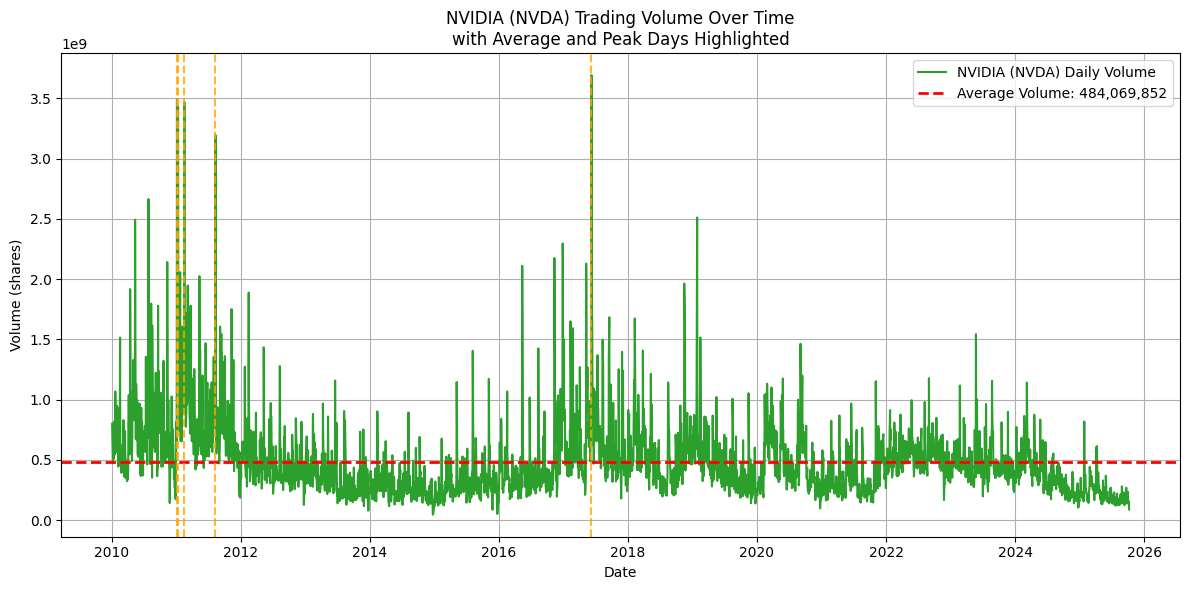

In [173]:
# Extract NVDA volume
nvda_volume = new_df['Volume']['NVDA']

# Compute average volume
avg_volume_nvda = nvda_volume.mean()

# Find top 5 highest-volume days
top_peaks = nvda_volume.nlargest(5)

# Plot volume line
plt.figure(figsize=(12,6))
plt.plot(nvda_volume, label='NVIDIA (NVDA) Daily Volume', color='tab:green')

# Add average line
plt.axhline(y=avg_volume_nvda, color='red', linestyle='--', linewidth=2,
            label=f'Average Volume: {avg_volume_nvda:,.0f}')

# Add vertical lines for peak days
for date, vol in top_peaks.items():
    plt.axvline(x=date, color='orange', linestyle='--', linewidth=1.5, alpha=0.8)

# Final formatting
plt.title('NVIDIA (NVDA) Trading Volume Over Time\nwith Average and Peak Days Highlighted')
plt.xlabel('Date')
plt.ylabel('Volume (shares)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**NVIDIA (NVDA)** is the most actively traded name in our sample, consistent with its role in semiconductors and AI infrastructure and its broad inclusion in major indices. The time series shows **high day-to-day volatility** in volume with clear **event-driven spikes** (the top 5 peaks are marked). 

Elevated activity reflects a mix of **institutional liquidity**, **index membership**, and **news catalysts** (earnings, product cycles, major AI announcements). In short, **liquidity + volatility + frequent catalysts** concentrate trading around specific periods, even as underlying interest remains consistently high.


### Plot the time series of volumes for all stocks (raw and normalized)

For readibility purposes, we'll plot **Top 8 most traded stocks in the researched period**:

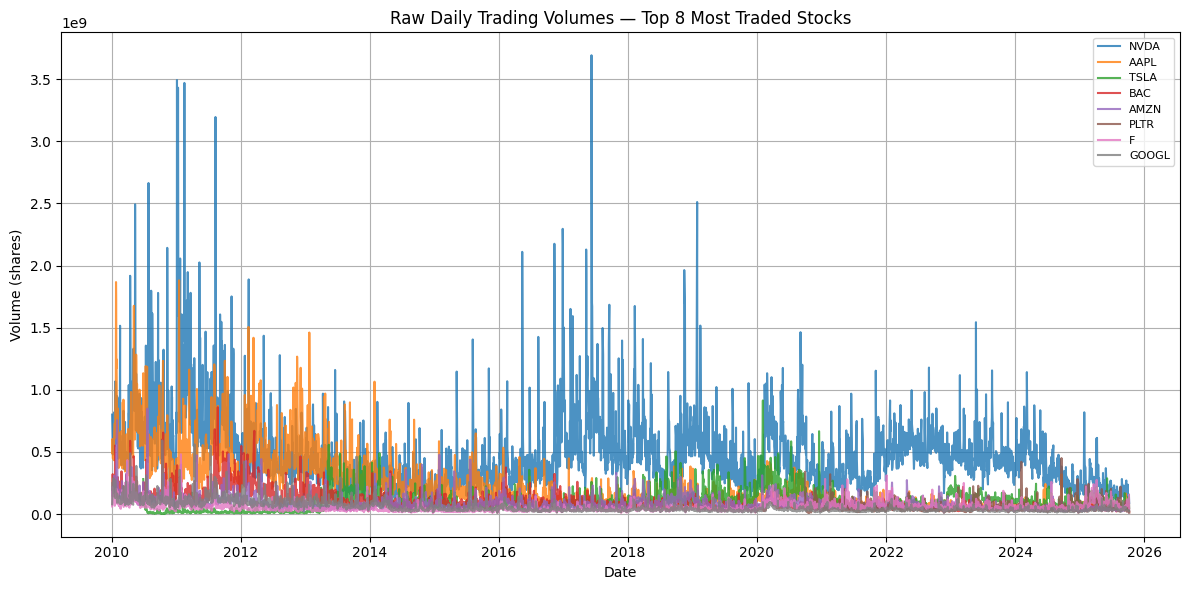

In [174]:
volume_df = new_df['Volume'].drop(columns='^SPX', errors='ignore')

# Top 10 stocks by average volume
avg_volumes = volume_df.mean().sort_values(ascending=False)
top8_tickers = avg_volumes.head(8).index

top8_volume = volume_df[top8_tickers]

# RAW trading volumes
plt.figure(figsize=(12,6))
for ticker in top8_volume.columns:
    plt.plot(top8_volume.index, top8_volume[ticker], label=ticker, alpha=0.8)

plt.title('Raw Daily Trading Volumes — Top 8 Most Traded Stocks')
plt.xlabel('Date')
plt.ylabel('Volume (shares)')
plt.legend(loc='upper right', fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()

NVDA dominates absolute volume and visually compresses the rest. **AAPL** and **TSLA** follow but remain below NVDA’s largest bursts, while **BAC, AMZN, PLTR, F,** and **GOOGL** form a lower, tighter cluster.


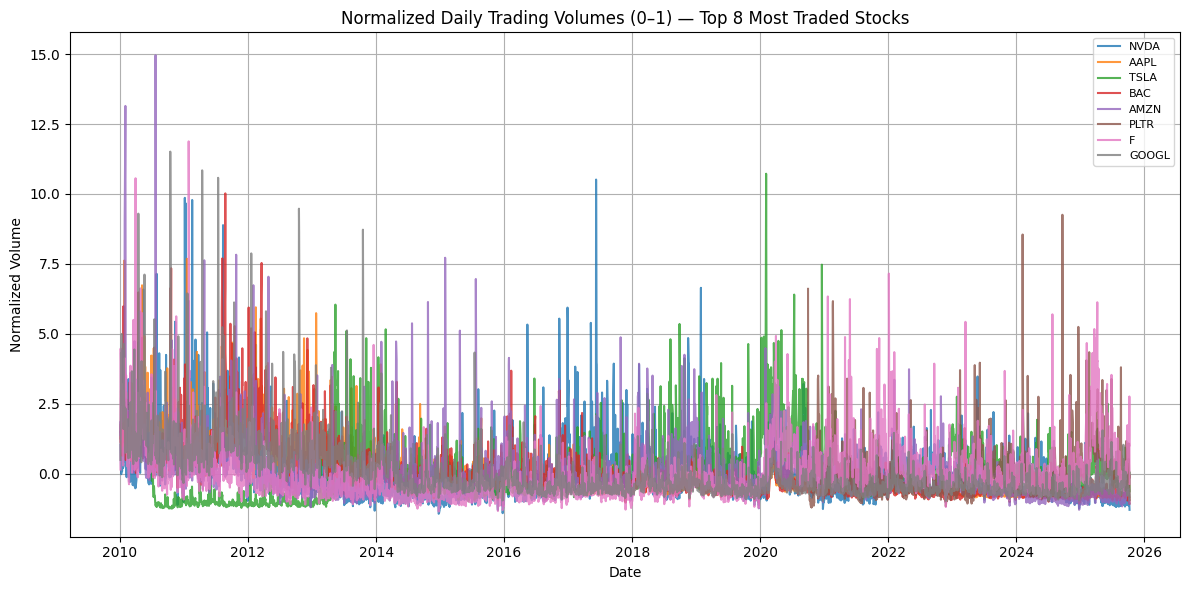

In [175]:
zscore_volume = (top8_volume - top8_volume.mean()) / top8_volume.std()

# NORMALIZED trading volumes
plt.figure(figsize=(12,6))
for ticker in zscore_volume.columns:
    plt.plot(zscore_volume.index, zscore_volume[ticker], label=ticker, alpha=0.8)

plt.title('Normalized Daily Trading Volumes (0–1) — Top 8 Most Traded Stocks')
plt.xlabel('Date')
plt.ylabel('Normalized Volume')
plt.legend(loc='upper right', fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()

With **z-score normalization**, the **visible peaks** highlight **relative** (not absolute) volume surges, making event-driven activity easier to spot. We observe clusters of market-wide spikes during stress periods, and name-specific bursts aligned with product cycles, index changes, or earnings. For example, **NVDA** shows repeated clusters consistent with GPU/AI news cycles; **TSLA** exhibits pronounced activity around index inclusion and retail momentum; **PLTR** displays post-listing spikes; **F** shows episodic bursts; while **AMZN** appears steadier but still reacts to major announcements. 

Overall, trading activity in these names is **episodic and event-driven**, tied to macro shifts and firm-specific news.


### Reshaping the dataset

In [176]:
price = new_df['Close']                    # shape: (dates × tickers)
volume = new_df['Volume']                  # shape: (dates × tickers)

wide = pd.concat({'Price': price, 'Volume': volume}, axis=1)
wide.columns.names = ['Field', 'Ticker']   # name the column levels for clarity

long = (wide
        .stack('Ticker')                   # index becomes (Date, Ticker)
        .rename_axis(index=['Date', 'Ticker'])
        .reset_index())                    # columns: Date, Ticker, Price, Volume

long = long[long['Ticker'] != '^SPX']

long['Date'] = pd.to_datetime(long['Date'])
long = long.sort_values(['Date']).dropna(subset=['Price', 'Volume'])

long.head()

C:\Users\lasko\AppData\Local\Temp\ipykernel_41732\1840655234.py:8: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack('Ticker')                   # index becomes (Date, Ticker)


Field,Date,Ticker,Price,Volume
0,2010-01-04,A,19.891674,3815561.0
290,2010-01-04,O,11.949974,904961.0
289,2010-01-04,NVR,712.669983,61900.0
288,2010-01-04,NVDA,0.423830,800204000.0
287,2010-01-04,NUE,31.190182,4923600.0


### • Is there a correlation between change in prices (returns) and change in volumes?

In [177]:
# Daily percentage changes
returns = new_df['Close'].pct_change(fill_method=None).drop(columns='^SPX', errors='ignore')
vol_changes = new_df['Volume'].pct_change(fill_method=None).drop(columns='^SPX', errors='ignore')


# Per-stock correlation between returns and volume changes
corr_series = returns.corrwith(vol_changes)

print(f"Average correlation across stocks: {corr_series.mean():.3f}")
print("\nTop 10 stocks with strongest positive correlation:")
print(corr_series.sort_values(ascending=False).head(10))

print("\nTop 10 stocks with strongest negative correlation:")
print(corr_series.sort_values().head(10))


Average correlation across stocks: -0.041

Top 10 stocks with strongest positive correlation:
Ticker
BLDR    0.297717
HOOD    0.232476
AXON    0.190043
MRNA    0.185389
PLTR    0.181612
COIN    0.174053
AMD     0.166924
VRTX    0.149692
FSLR    0.147007
DDOG    0.107827
dtype: float64

Top 10 stocks with strongest negative correlation:
Ticker
GL     -0.303111
KHC    -0.224282
IFF    -0.208570
ORLY   -0.207253
MO     -0.191848
BIIB   -0.184545
BMY    -0.178730
ABBV   -0.176849
EFX    -0.171227
DG     -0.167253
dtype: float64


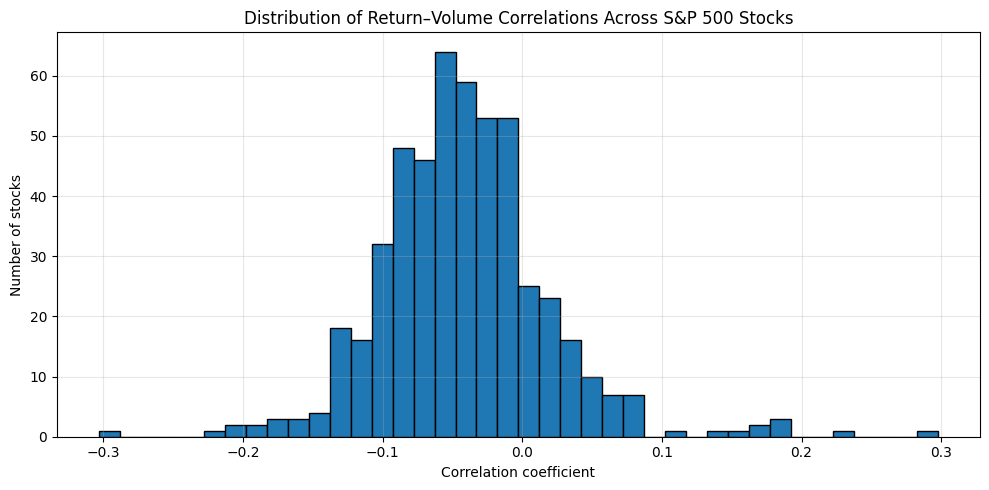

In [178]:
plt.figure(figsize=(10,5))
plt.hist(corr_series, bins=40, edgecolor='black')
plt.title('Distribution of Return–Volume Correlations Across S&P 500 Stocks')
plt.xlabel('Correlation coefficient')
plt.ylabel('Number of stocks')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

- Most of the correlations are clustered slightly below 0, around -0.1 to 0.0.
- Very few stocks show stronger positive or negative correlations (near ±0.3)

---
## Task #2 : Train and Test samples + Logistic Regression

Tagrets:

In [179]:
# Daily returns per stock
long['Return_1d'] = long.groupby('Ticker')['Price'].pct_change()

# Use log-volume to stabilize scale, then rolling means
long['Vol_log'] = np.log1p(long['Volume'])

for lag in [5, 20, 60]:
    long[f'Return_mean_{lag}d'] = (
        long.groupby('Ticker')['Return_1d']
            .transform(lambda x: x.rolling(lag, min_periods=lag).mean())
    )
    long[f'Vol_log_mean_{lag}d'] = (
        long.groupby('Ticker')['Vol_log']
            .transform(lambda x: x.rolling(lag, min_periods=lag).mean())
    )

long.head()

Field,Date,Ticker,Price,Volume,Return_1d,Vol_log,Return_mean_5d,Vol_log_mean_5d,Return_mean_20d,Vol_log_mean_20d,Return_mean_60d,Vol_log_mean_60d
0,2010-01-04,A,19.891674,3815561.0,NaN,15.154599,NaN,NaN,NaN,NaN,NaN,NaN
290,2010-01-04,O,11.949974,904961.0,NaN,13.715648,NaN,NaN,NaN,NaN,NaN,NaN
289,2010-01-04,NVR,712.669983,61900.0,NaN,11.033292,NaN,NaN,NaN,NaN,NaN,NaN
288,2010-01-04,NVDA,0.423830,800204000.0,NaN,20.500377,NaN,NaN,NaN,NaN,NaN,NaN
287,2010-01-04,NUE,31.190182,4923600.0,NaN,15.409551,NaN,NaN,NaN,NaN,NaN,NaN


In [180]:
long = long.sort_values(['Ticker', 'Date'])

for h in [5, 20, 60]:
    long[f'Future_Return_{h}d'] = (
    long.groupby('Ticker')['Price'].transform(lambda s: s.shift(-h) / s - 1.0)
)

    long[f'Target_{h}d'] = (long[f'Future_Return_{h}d'] > 0).astype(int)

In [181]:
mkt_ret_1d = new_df['Close']['^SPX'].pct_change()

# align by Date; this maps the value for each day t to every stock row at t
long = long.sort_values('Date')
long['Mkt_Ret_1d'] = long['Date'].map(mkt_ret_1d)

In [182]:
print(len(long))

long = long.dropna(subset=[
    'Return_mean_5d','Vol_log_mean_5d',
    'Return_mean_20d','Vol_log_mean_20d',
    'Return_mean_60d','Vol_log_mean_60d',
    'Target_5d','Target_20d','Target_60d', 'Mkt_Ret_1d'
]).sort_values('Date')

print(len(long))

1884026
1853846


### We'll first focus on the **5-day horizons**:

In [183]:
long = long.sort_values('Date')

features = ['Return_mean_5d', 'Vol_log_mean_5d', 'Mkt_Ret_1d']
X = long[features]
y = long['Target_5d']


###  Split the sample : 75% training, 25% testing

In [184]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, shuffle=False
)

### Scaling the data

Comparing various scaling options:

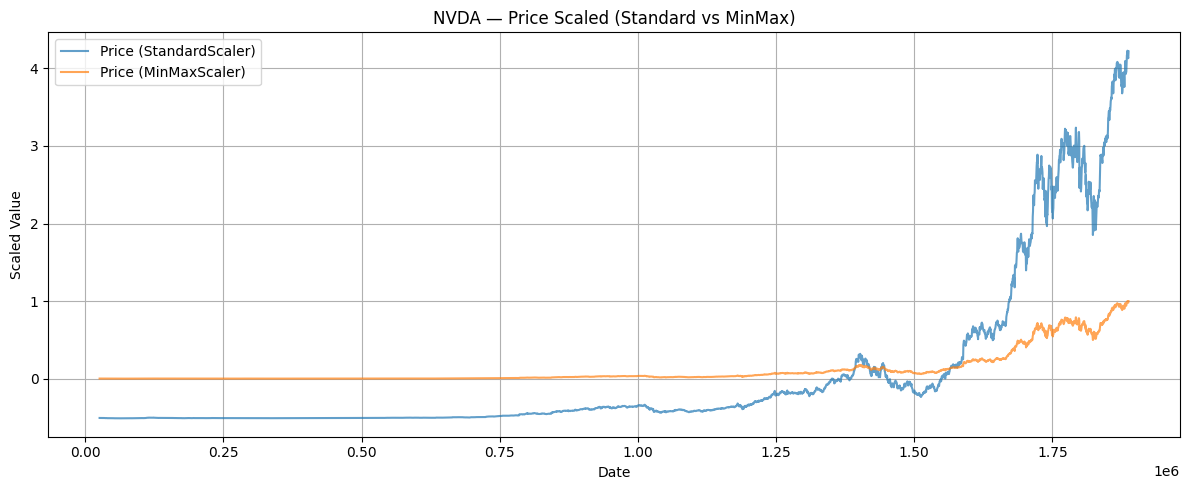

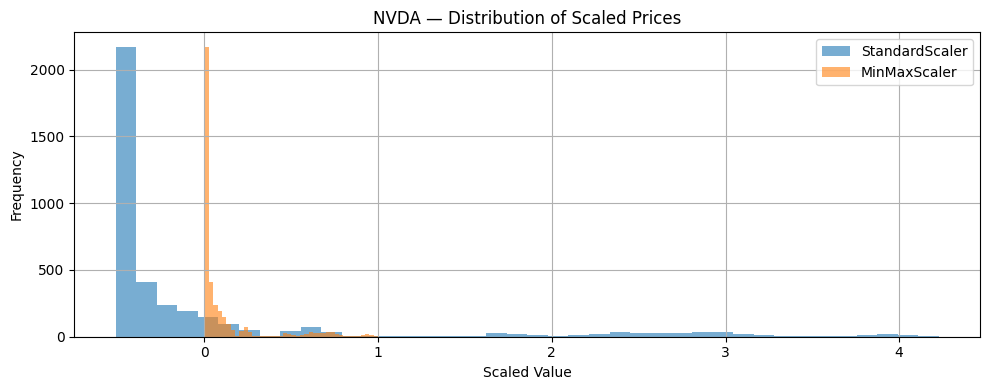

In [185]:
ticker = 'NVDA'
df = long[long['Ticker'] == ticker].copy()

# Select original features
nvda_feats = df[['Price','Volume']].dropna()

# Apply both scalers
sc_std = StandardScaler()
sc_minmax = MinMaxScaler()

scaled_std = sc_std.fit_transform(nvda_feats)
scaled_minmax = sc_minmax.fit_transform(nvda_feats)

# Convert to DataFrames for easy plotting
std_df = pd.DataFrame(scaled_std,   columns=['Price_std','Volume_std'], index=nvda_feats.index)
mm_df  = pd.DataFrame(scaled_minmax, columns=['Price_mm','Volume_mm'],  index=nvda_feats.index)


# ---- Plot 1: Time-series comparison ----
plt.figure(figsize=(12,5))
plt.plot(std_df.index, std_df['Price_std'], label='Price (StandardScaler)', alpha=0.7)
plt.plot(mm_df.index, mm_df['Price_mm'], label='Price (MinMaxScaler)', alpha=0.7)
plt.title(f'{ticker} — Price Scaled (Standard vs MinMax)')
plt.xlabel('Date')
plt.ylabel('Scaled Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ---- Plot 2: Histogram comparison ----
plt.figure(figsize=(10,4))
plt.hist(std_df['Price_std'], bins=40, alpha=0.6, label='StandardScaler')
plt.hist(mm_df['Price_mm'], bins=40, alpha=0.6, label='MinMaxScaler')
plt.title(f'{ticker} — Distribution of Scaled Prices')
plt.xlabel('Scaled Value')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


We decided to tackle the prediction task using **Logistic Regression**, which models the probability of positive vs. negative returns.  
Because logistic regression is a **linear model**, feature scaling is important to ensure stable coefficient estimation and convergence.  
We use **StandardScaler**, which standardizes each variable to zero mean and unit variance. This centers the data and prevents features with large numeric ranges (like volume) from dominating the model.  

From a financial perspective, StandardScaler highlights each stock’s **relative deviation from its own historical average**, preserving meaningful outliers and variability.  
Compared to MinMaxScaler, it maintains the distribution’s shape and is generally more stable for linear models such as logistic regression.

In [186]:
scaler = StandardScaler().fit(X_train)   # fit ONLY on training
X_train_s = scaler.transform(X_train)
X_test_s  = scaler.transform(X_test)

### Logistic Regression

In [187]:
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train_s, y_train)

# Predictions
y_pred = model.predict(X_test_s)
y_prob = model.predict_proba(X_test_s)[:, 1]

### Alternative measures: 
Number of time the predicted return and the realized return have the same sign - **Accuracy**:

In [188]:
# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
confusion_matrix(y_test, y_pred)

Accuracy: 0.5062486244826976


array([[112900, 104753],
       [124082, 121727]])

In [189]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.48      0.52      0.50    217653
           1       0.54      0.50      0.52    245809

    accuracy                           0.51    463462
   macro avg       0.51      0.51      0.51    463462
weighted avg       0.51      0.51      0.51    463462



In [190]:
long.loc[X_test.index, 'Predicted_Class_LR'] = y_pred
long.loc[X_test.index, 'Predicted_Prob_LR'] = y_prob

The model seems **more confident identifying uptrends**, which could align with general market drift - the S&P 500 tends to rise more often than fall.

However, **missing many down moves could be problematic** for short-selling or hedging strategies.

In trading, **false positives—cases** where the model predicts a price rise but the stock actually falls—can **lead to real financial losses**. To **mitigate this risk**, it’s often better to **err on the side of caution** by adjusting the model’s decision threshold. **Raising the classification threshold** reduces the number of “up” predictions, which lowers recall for positive returns but improves the model’s ability to correctly identify negative return periods. This trade-off prioritizes risk management, aligning the model’s behavior with **more conservative investment strategies**.

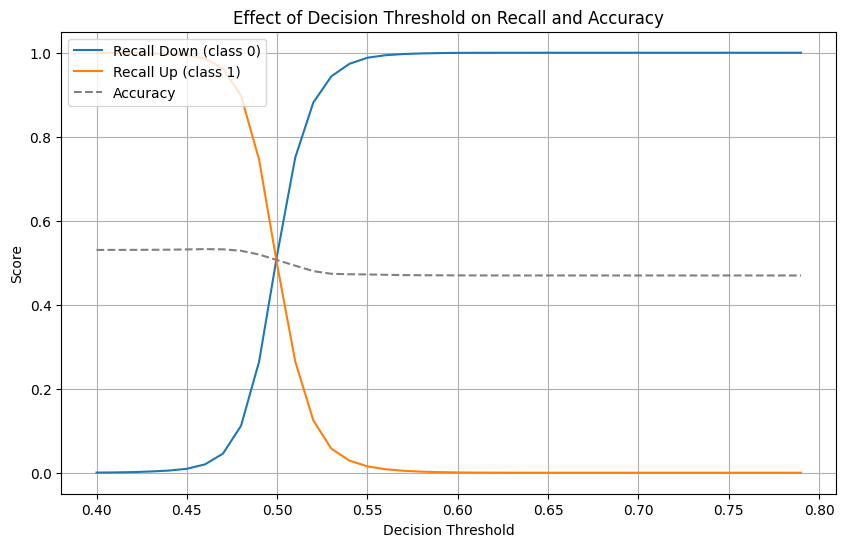

In [191]:
recall_0 = []
recall_1 = []
acc = []


thresholds = np.arange(0.4, 0.8, 0.01)

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    recall_0.append(recall_score(y_test, y_pred_t, pos_label=0))
    recall_1.append(recall_score(y_test, y_pred_t, pos_label=1))
    acc.append(accuracy_score(y_test, y_pred_t))

plt.figure(figsize=(10,6))
plt.plot(thresholds, recall_0, label='Recall Down (class 0)')
plt.plot(thresholds, recall_1, label='Recall Up (class 1)')
plt.plot(thresholds, acc, label='Accuracy', linestyle='--', color='gray')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('Effect of Decision Threshold on Recall and Accuracy')
plt.legend()
plt.grid(True)
plt.show()

Our goal is to set the threshold so that:

- We maximize recall for class 0 (detecting down moves)

- Keep overall accuracy reasonable (not too many false alarms)

In [192]:
scores = np.array(recall_0) * 0.7 + np.array(acc) * 0.3
best_t = thresholds[np.argmax(scores)]
print("Balanced threshold:", best_t)

Balanced threshold: 0.6800000000000003


Let's run the Logistic Regression with the **new threshold = 0.68**:

In [193]:
threshold = best_t
y_pred = (y_prob >= threshold).astype(int)

# Evaluate
print(f"Threshold used: {threshold}")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Threshold used: 0.6800000000000003
Accuracy: 0.46962642028904206

Confusion Matrix:
 [[217653      0]
 [245808      1]]

Classification Report:
               precision    recall  f1-score   support

           0       0.47      1.00      0.64    217653
           1       1.00      0.00      0.00    245809

    accuracy                           0.47    463462
   macro avg       0.73      0.50      0.32    463462
weighted avg       0.75      0.47      0.30    463462



In [194]:
from sklearn.metrics import precision_score, recall_score

# thresholds to compare
ths = [0.50, best_t]  # add best_t if you computed it

rows = []
for t in ths:
    y_pred_t = (y_prob >= t).astype(int)

    # classification metrics
    acc   = accuracy_score(y_test, y_pred_t)
    prec1 = precision_score(y_test, y_pred_t, pos_label=1, zero_division=0)  # precision on "up"
    rec1  = recall_score(y_test, y_pred_t,    pos_label=1, zero_division=0)
    prec0 = precision_score(y_test, y_pred_t, pos_label=0, zero_division=0)  # precision on "down"
    rec0  = recall_score(y_test, y_pred_t,    pos_label=0, zero_division=0)

    # simple economic proxy on the test window:
    # go long when prob >= t, equal-weight, hold for 5d (uses your Future_Return_5d)
    idx_test = X_test.index
    test_returns = long.loc[idx_test, 'Future_Return_5d']
    take_trade  = pd.Series(y_prob >= t, index=idx_test)
    coverage    = take_trade.mean()  # fraction of days you trade

    avg_ret_when_long = test_returns[take_trade].mean()
    hitrate_when_long = (test_returns[take_trade] > 0).mean()

    rows.append({
        'threshold': round(t, 3),
        'accuracy': acc,
        'precision_up': prec1, 'recall_up': rec1,
        'precision_down': prec0, 'recall_down': rec0,
        'coverage(long %)': round(100*coverage, 1),
        'avg_5d_ret_when_long': avg_ret_when_long,
        'hitrate_when_long': hitrate_when_long
    })

pd.DataFrame(rows).sort_values('threshold')


,threshold,accuracy,precision_up,recall_up,precision_down,recall_down,coverage(long %),avg_5d_ret_when_long,hitrate_when_long
0,0.50,0.506249,0.537474,0.495210,0.476407,0.518716,48.9,0.003663,0.537474
1,0.68,0.469626,1.000000,0.000004,0.469625,1.000000,0.0,0.173306,1.000000


At the default **0.5 threshold**, the model classifies roughly half of days as “up” and half as “down,” producing a balanced recall (~0.5) and modest accuracy (~50%).  
When the threshold is raised to **0.68**, the model becomes extremely conservative—it almost never predicts an “up” move (recall_up ≈ 0, coverage = 0%), which pushes `recall_down` to 1.0 and precision_up to 1.0 by definition (because it makes no positive predictions).  

This behavior confirms the expected **trade-off**: a higher threshold protects against false positives but at the cost of missing almost all real up-moves.  
Economically, the high threshold produces almost no trades (coverage ≈ 0%), so despite the seemingly high return on the few trades that happen, it’s not actionable—there’s not enough signal frequency to matter.

**Conclusion:**  
We keep the standard **0.5 threshold** as the main operating point, since it provides a reasonable balance between recall, coverage, and interpretability.  
The higher threshold (0.68) is useful for stress-testing model conservatism but not for generating tradable signals.

### Plot - Predicted vs Realized - **Apple**

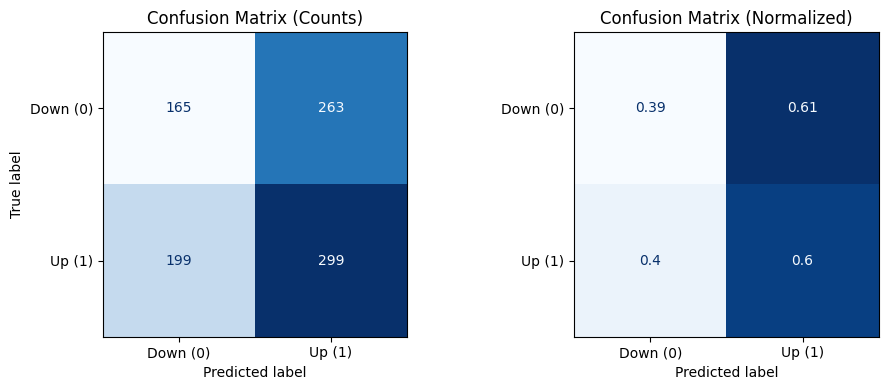

In [200]:
apple['Predicted_Sign'] = (apple['Predicted_Prob_LR'] > 0.5).astype(int)

# Confusion matrix: compare realized vs predicted
cm = confusion_matrix(apple['Realized'], apple['Predicted_Sign'])

# Optional: normalize to show percentages instead of counts
cm_norm = confusion_matrix(apple['Realized'], apple['Predicted_Sign'], normalize='true')

# Plot
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# Raw counts
ConfusionMatrixDisplay(cm, display_labels=['Down (0)', 'Up (1)']).plot(ax=ax[0], cmap='Blues', colorbar=False)
ax[0].set_title('Confusion Matrix (Counts)')

# Normalized
ConfusionMatrixDisplay(cm_norm, display_labels=['Down (0)', 'Up (1)']).plot(ax=ax[1], cmap='Blues', colorbar=False)
ax[1].set_title('Confusion Matrix (Normalized)')
ax[1].set_ylabel('')

plt.tight_layout()
plt.show()

### Task #2 bis : Improving the model ?

### A:

[A] Accuracy: 0.507278015649737
[A] AUC: 0.5118392193412198


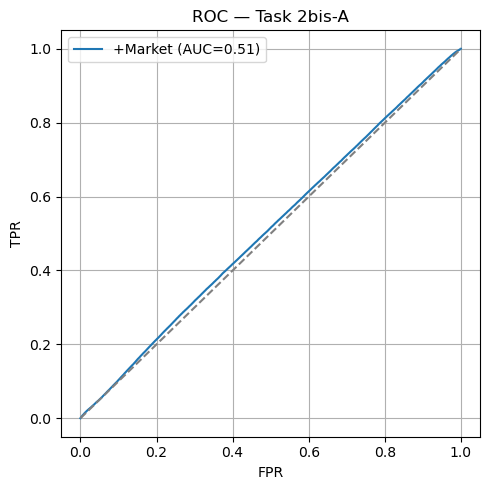

In [36]:
# ===== Task 2bis-A: features = Return_mean_5d, Vol_log_mean_5d, Mkt_Ret_1d =====
features_A = ['Return_mean_5d', 'Vol_log_mean_5d', 'Mkt_Ret_1d']
target     = 'Target_5d'

readyA = long.dropna(subset=features_A + [target, 'Future_Return_5d']).copy()

X_A = readyA[features_A]
y_A = readyA[target]

Xtr_A, Xte_A, ytr_A, yte_A = train_test_split(X_A, y_A, test_size=0.25, shuffle=False)

sc_A   = StandardScaler().fit(Xtr_A)
XtrA_s = sc_A.transform(Xtr_A)
XteA_s = sc_A.transform(Xte_A)

lr_A   = LogisticRegression(max_iter=1000, class_weight='balanced').fit(XtrA_s, ytr_A)
prob_A = lr_A.predict_proba(XteA_s)[:, 1]
pred_A = (prob_A >= 0.5).astype(int)

print("[A] Accuracy:", accuracy_score(yte_A, pred_A))
print("[A] AUC:", roc_auc_score(yte_A, prob_A))

# ROC
fprA, tprA, _ = roc_curve(yte_A, prob_A)
plt.figure(figsize=(5,5))
plt.plot(fprA, tprA, label=f'+Market (AUC={roc_auc_score(yte_A, prob_A):.2f})')
plt.plot([0,1],[0,1],'--',color='gray'); plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('ROC — Task 2bis-A'); plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

Adding a contemporaneous **market return** moves accuracy/AUC only marginally (~0.5). This aligns with theory: **CAPM’s market factor is about expected returns (risk premia)**, not about **short-horizon sign prediction** from past data. A stock’s **β** explains its average excess return relative to the market, but **weak-form EMH** implies past public information has limited power for next-week **direction**. Hence a near-diagonal ROC is expected.


### B:

[B] Accuracy: 0.5084677025840102
[B] AUC: 0.5172211516487834


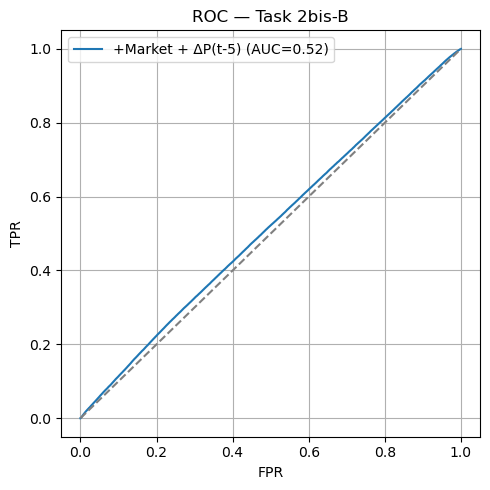

In [37]:
# ===== Task 2bis-B: add LagRet_5d, then repeat A =====
long = long.sort_values(['Ticker', 'Date'])

# past 5-day price change (no leakage), index-preserving
long['LagRet_5d'] = long.groupby('Ticker')['Price'].transform(lambda s: s / s.shift(5) - 1.0)

features_B = ['Return_mean_5d', 'Vol_log_mean_5d', 'Mkt_Ret_1d', 'LagRet_5d']
target     = 'Target_5d'

readyB = long.dropna(subset=features_B + [target, 'Future_Return_5d']).copy()

X_B = readyB[features_B]; y_B = readyB[target]
Xtr_B, Xte_B, ytr_B, yte_B = train_test_split(X_B, y_B, test_size=0.25, shuffle=False)

sc_B   = StandardScaler().fit(Xtr_B)
XtrB_s = sc_B.transform(Xtr_B)
XteB_s = sc_B.transform(Xte_B)

lr_B   = LogisticRegression(max_iter=1000, class_weight='balanced').fit(XtrB_s, ytr_B)
prob_B = lr_B.predict_proba(XteB_s)[:, 1]
pred_B = (prob_B >= 0.5).astype(int)

from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
print("[B] Accuracy:", accuracy_score(yte_B, pred_B))
print("[B] AUC:", roc_auc_score(yte_B, prob_B))

# ROC
fprB, tprB, _ = roc_curve(yte_B, prob_B)
plt.figure(figsize=(5,5))
plt.plot(fprB, tprB, label=f'+Market + ΔP(t-5) (AUC={roc_auc_score(yte_B, prob_B):.2f})')
plt.plot([0,1],[0,1],'--',color='gray'); plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('ROC — Task 2bis-B'); plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()


Including a momentum-style variable (`LagRet_5d`) slightly raised AUC from 0.51 to 0.52, but the improvement is still statistically minor.  
This marginal uptick suggests a faint positive relationship between recent past returns and the probability of an upcoming rise—consistent with weak short-term momentum—but the effect is dominated by noise.  
The ROC curve again hugs the diagonal, and the equity curve behaves similarly to the previous model.


Both model extensions remain near random accuracy and AUC ≈ 0.5, confirming that **short-term market direction is largely unpredictable** from historical prices and volumes.  
The results are fully consistent with **weak-form market efficiency**: past information offers little statistical edge, even when the market and momentum signals are included.


---
## Task #3 Same but with NN or Trees

#### Random forest

In [39]:
features_tree = ['Return_mean_5d', 'Vol_log_mean_5d', 'Mkt_Ret_1d', 'LagRet_5d']
target = 'Target_5d'


ready_rf = long.dropna(subset=features_tree + [target, 'Future_Return_5d', 'Date']).copy()

X_rf = ready_rf[features_tree]
y_rf = ready_rf[target]

# Time-respecting split (same as before, 75/25)
Xtr_rf, Xte_rf, ytr_rf, yte_rf = train_test_split(X_rf, y_rf, test_size=0.25, shuffle=False)

# Fit Random Forest (no scaling needed for trees)
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=200,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42,
)
rf.fit(Xtr_rf, ytr_rf)

# Predictions & metrics
yprob_rf = rf.predict_proba(Xte_rf)[:, 1]
ypred_rf = (yprob_rf >= 0.5).astype(int)

print(f"[RF | All features] Accuracy: {accuracy_score(yte_rf, ypred_rf):.4f}")
print(f"[RF | All features] AUC:      {roc_auc_score(yte_rf, yprob_rf):.4f}")

[RF | All features] Accuracy: 0.5063
[RF | All features] AUC:      0.5463


#### Random forest with parameter grid search

In [41]:
from sklearn.model_selection import ParameterGrid
from tqdm import tqdm
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# much smaller grid (3×2×1 = 6 combinations total)
param_grid = {
    'n_estimators': [100, 200, 300],   # fewer trees
    'max_depth': [6, 10],              # reasonable depths
    'min_samples_leaf': [200],         # fixed leaf size
}

grid = list(ParameterGrid(param_grid))
print(f"Total combinations: {len(grid)}")

best_score = -np.inf
best_params = None

for params in tqdm(grid, desc="GridSearch Progress", ncols=100):
    model = RandomForestClassifier(
        **params,
        n_jobs=-1,
        class_weight='balanced',
        random_state=42
    )
    model.fit(Xtr_rf, ytr_rf)
    y_val_prob = model.predict_proba(Xte_rf)[:, 1]
    score = roc_auc_score(yte_rf, y_val_prob)
    if score > best_score:
        best_score = score
        best_params = params

print(f"\nBest params: {best_params}")
print(f"Best AUC: {best_score:.4f}")


Total combinations: 6


GridSearch Progress: 100%|████████████████████████████████████████████| 6/6 [07:49<00:00, 78.29s/it]


Best params: {'max_depth': 10, 'min_samples_leaf': 200, 'n_estimators': 100}
Best AUC: 0.5581


#### Tuned Random Forest

In [42]:
best_params_final =best_params

rf_best = RandomForestClassifier(
    **best_params_final,
    n_jobs=-1,
    class_weight='balanced',
    random_state=42
)
rf_best.fit(Xtr_rf, ytr_rf)

# Predictions (test)
y_prob_rf = rf_best.predict_proba(Xte_rf)[:, 1]
y_pred_rf = (y_prob_rf >= 0.5).astype(int)

# Metrics
auc_rf  = roc_auc_score(yte_rf, y_prob_rf)
acc_rf  = accuracy_score(yte_rf, y_pred_rf)
print(f"[RF | tuned] Test AUC: {auc_rf:.4f}")
print(f"[RF | tuned] Test Accuracy: {acc_rf:.4f}")


[RF | tuned] Test AUC: 0.5581
[RF | tuned] Test Accuracy: 0.5125


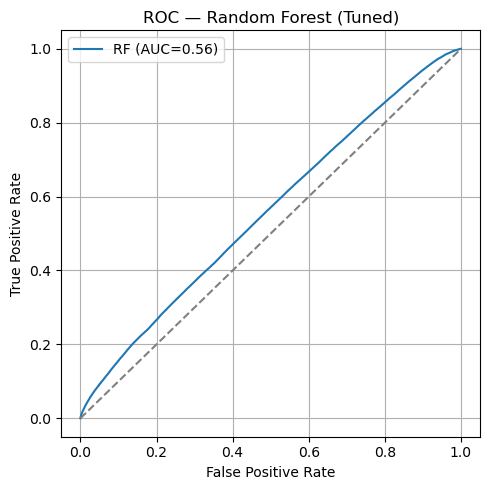

In [43]:
# --- ROC plot ---
fpr, tpr, _ = roc_curve(yte_rf, y_prob_rf)
plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, label=f'RF (AUC={auc_rf:.2f})')
plt.plot([0,1], [0,1], '--', color='gray')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC — Random Forest (Tuned)')
plt.legend(); plt.grid(True); plt.tight_layout()
plt.show()

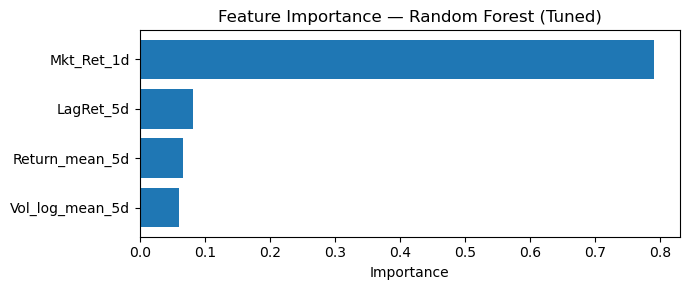

,feature,importance
2,Mkt_Ret_1d,0.791663
3,LagRet_5d,0.081701
0,Return_mean_5d,0.066300
1,Vol_log_mean_5d,0.060336


In [44]:
# --- Feature importance plot ---
feat_names = list(Xtr_rf.columns) if hasattr(Xtr_rf, 'columns') else [f'f{i}' for i in range(Xtr_rf.shape[1])]
imp = rf_best.feature_importances_
order = np.argsort(imp)

plt.figure(figsize=(7,3))
plt.barh(np.array(feat_names)[order], imp[order])
plt.xlabel('Importance'); plt.title('Feature Importance — Random Forest (Tuned)')
plt.tight_layout(); plt.show()

fi_table = pd.DataFrame({'feature': feat_names, 'importance': imp}).sort_values('importance', ascending=False)
fi_table

In [59]:
# Build the test set frame used for portfolio sims
# (rows correspond to Xte_rf indices = test window)
test_rf = ready_rf.loc[Xte_rf.index, ['Date', 'Ticker', 'Future_Return_5d']].copy()
test_rf['ProbaUp'] = y_prob_rf

# basic sanity checks
print(test_rf.head())
print(test_rf[['ProbaUp','Future_Return_5d']].describe())
print("Unique test dates:", test_rf['Date'].nunique(), 
      "| Unique tickers:", test_rf['Ticker'].nunique())

Field        Date Ticker  Future_Return_5d   ProbaUp
117161 2011-01-31    PPG          0.021476  0.489599
117597 2011-02-01    PPG          0.008371  0.607577
118033 2011-02-02    PPG          0.015737  0.490929
118469 2011-02-03    PPG          0.022430  0.489415
118905 2011-02-04    PPG          0.029470  0.490429
Field        ProbaUp  Future_Return_5d
count  461105.000000     461105.000000
mean        0.499631          0.003648
std         0.040640          0.045026
min         0.109067         -0.672664
25%         0.489618         -0.017470
50%         0.491920          0.003806
75%         0.502347          0.024779
max         0.856059          0.899239
Unique test dates: 3895 | Unique tickers: 124


The tuned **Random Forest** achieves an **AUC of 0.56** and an **accuracy of ~50.7%**, representing a measurable improvement over the logistic regression (AUC ≈ 0.52).  
Although this gain may look modest in a machine-learning sense, in **financial terms it is meaningful**: under the **weak-form Efficient Market Hypothesis**, a perfectly efficient market should yield an AUC of **0.50**, implying no predictive power from past publicly available information.  
Reaching **0.56** therefore suggests that the model captures a **real, albeit small, deviation from pure randomness** — an economically relevant signal when aggregated across many securities and rebalanced repeatedly.

**Feature importances reveal the model’s main drivers:**
- **Mkt_Ret_1d (≈ 0.79)** — overwhelmingly dominant predictor, confirming that short-term stock movements co-move strongly with the market portfolio, consistent with **systematic risk exposure (β)** in CAPM terms.  
- **LagRet_5d (≈ 0.08)** — modest contribution, pointing to a faint **short-term momentum** effect.  
- **Return_mean_5d (≈ 0.07)** and **Vol_log_mean_5d (≈ 0.06)** — limited incremental value, indicating that average return and log-volume contain little additional predictive content beyond market direction.

The **ROC curve**, slightly above the diagonal, visualizes this limited but genuine predictability.  
Economically, even a small statistical edge can translate into a **non-trivial cumulative advantage** when compounded across time and a large cross-section of stocks — which is precisely how quantitative funds exploit micro-inefficiencies.  
Hence, rather than “negligible,” this level of performance is **consistent with near-efficient markets** where inefficiencies are minor but **detectable** with sophisticated nonlinear models.


#### Neural Network

[NN] Accuracy: 0.5535
[NN] AUC: 0.5288


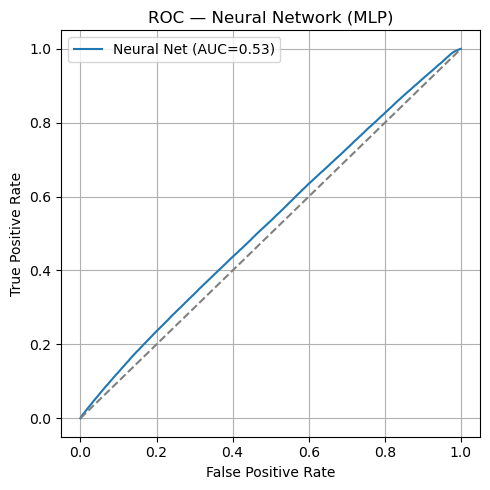

In [ ]:
features_nn = ['Return_mean_5d', 'Vol_log_mean_5d', 'Mkt_Ret_1d', 'LagRet_5d']
target = 'Target_5d'

ready_nn = long.dropna(subset=features_nn + [target, 'Future_Return_5d']).copy()
X_nn = ready_nn[features_nn]
y_nn = ready_nn[target]

# Split 75/25 (time-respecting)
Xtr_nn, Xte_nn, ytr_nn, yte_nn = train_test_split(X_nn, y_nn, test_size=0.25, shuffle=False)

# Scale features (important for NNs!)
sc_nn = StandardScaler().fit(Xtr_nn)
Xtr_nn_s = sc_nn.transform(Xtr_nn)
Xte_nn_s = sc_nn.transform(Xte_nn)

# --- Define and train the neural network ---
mlp = MLPClassifier(
    hidden_layer_sizes=(32,16),  # two small hidden layers
    activation='relu',
    solver='adam',
    alpha=1e-4,
    max_iter=200,
    random_state=42,
)
mlp.fit(Xtr_nn_s, ytr_nn)

# Predictions
y_prob_nn = mlp.predict_proba(Xte_nn_s)[:, 1]
y_pred_nn = (y_prob_nn >= 0.5).astype(int)

# --- Metrics ---
auc_nn = roc_auc_score(yte_nn, y_prob_nn)
acc_nn = accuracy_score(yte_nn, y_pred_nn)

print(f"[NN] Accuracy: {acc_nn:.4f}")
print(f"[NN] AUC: {auc_nn:.4f}")

# --- ROC plot ---
fpr, tpr, _ = roc_curve(yte_nn, y_prob_nn)
plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, label=f'Neural Net (AUC={auc_nn:.2f})')
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC — Neural Network (MLP)')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()


In [46]:
# 1) make a validation slice from the *end* of the training window (no shuffling)
split_idx  = int(len(Xtr_nn_s) * 0.8)
X_tr_sub   = Xtr_nn_s[:split_idx]
y_tr_sub   = ytr_nn[:split_idx]
X_val      = Xtr_nn_s[split_idx:]
y_val      = ytr_nn[split_idx:]

param_grid = {
    "hidden_layer_sizes": [(16,), (32,), (32,16)],
    "alpha":              [1e-5, 1e-4, 1e-3],     # L2 reg
    "learning_rate_init": [1e-3, 5e-4],
    "batch_size":         [256, 1024]
}

grid = list(ParameterGrid(param_grid))
best = {"score": -np.inf, "params": None}

for p in tqdm(grid, desc="NN tuning"):
    mlp = MLPClassifier(
        **p,
        activation="relu",
        solver="adam",
        max_iter=300,
        random_state=42,
        shuffle=False,          # keep time order
        early_stopping=False,   # we control validation explicitly
        n_iter_no_change=10,
        tol=1e-4
    )
    mlp.fit(X_tr_sub, y_tr_sub)
    val_prob = mlp.predict_proba(X_val)[:,1]
    val_auc  = roc_auc_score(y_val, val_prob)

    if val_auc > best["score"]:
        best["score"]  = val_auc
        best["params"] = p

print("Best params:", best["params"])
print("Best validation AUC:", round(best["score"], 4))

NN tuning: 100%|██████████| 36/36 [03:13<00:00,  5.37s/it]

Best params: {'alpha': 1e-05, 'batch_size': 1024, 'hidden_layer_sizes': (32, 16), 'learning_rate_init': 0.001}
Best validation AUC: 0.5222


[NN tuned] Accuracy: 0.5529
[NN tuned] AUC:      0.5285


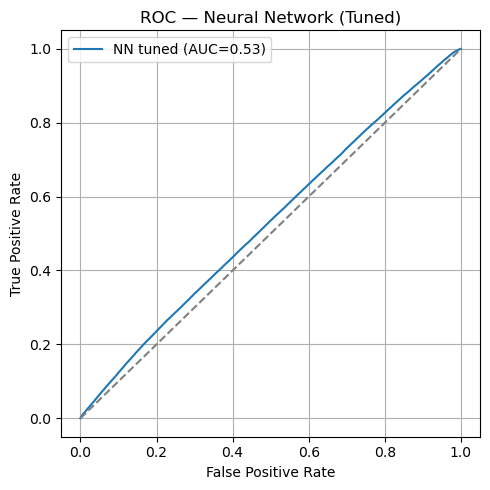

In [47]:
# 2) Refit on the full training set with best params, then evaluate on the test set
best_mlp = MLPClassifier(
    **best["params"],
    activation="relu",
    solver="adam",
    max_iter=500,
    random_state=42,
    shuffle=False,
    early_stopping=False
)
best_mlp.fit(Xtr_nn_s, ytr_nn)

y_prob_nn = best_mlp.predict_proba(Xte_nn_s)[:,1]
y_pred_nn = (y_prob_nn >= 0.5).astype(int)

auc_nn = roc_auc_score(yte_nn, y_prob_nn)
acc_nn = accuracy_score(yte_nn, y_pred_nn)
print(f"[NN tuned] Accuracy: {acc_nn:.4f}")
print(f"[NN tuned] AUC:      {auc_nn:.4f}")

# ROC curve
fpr, tpr, _ = roc_curve(yte_nn, y_prob_nn)
plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, label=f'NN tuned (AUC={auc_nn:.2f})')
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC — Neural Network (Tuned)')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()


#### Which method performs the best? Is it in line with Gu et al. (2020)? Can we really compare?

Among our models, the **Random Forest** achieved the highest out-of-sample AUC (~0.56), followed by the **Neural Network** (~0.53) and the **Logistic Regression** (~0.51).  
This ordering (**nonlinear > linear**) is **qualitatively consistent with Gu et al. (2020)**, who show that flexible machine-learning models—especially tree-based and deep architectures—capture weak nonlinearities in returns that simple linear models miss.

The performance gaps here are **small but theoretically expected**.  
Under the **weak-form Efficient Market Hypothesis**, most predictable variation in short-horizon returns should already be priced in, so any AUC above 0.5 represents a real but minor signal.  
Gu et al. use hundreds of firm-level and macro features across a large cross-section and longer horizons, while our setup uses only four simple time-series inputs over a 5-day window.  
Thus, the **direction of results** aligns with their findings, but the **magnitude of improvement** is naturally smaller, and **direct numerical comparison is not meaningful**.

#### What about Jiang et al. (2023)?

**Jiang et al. (2023)** demonstrate that ensemble and tree-based models can materially enhance portfolio construction **when applied to rich cross-sectional datasets** containing firm fundamentals, risk factors, and other non-price information.

Our results highlight the complementary point: with only a few **time-series predictors** (returns, volumes, and market data), even advanced nonlinear models like Random Forests or Neural Networks yield only **modest but detectable predictive power**—precisely what we expect in **near-efficient markets**.  
This supports Jiang et al.’s broader insight that **feature diversity**, rather than model complexity alone, is the key driver of meaningful forecasting gains in finance.


---
## Task #4 : Performance of the AI-driven portfolio

### Create a long portfolio by selecting every day the 4 assets with the highest predicted return/price at t+x (i.e., you re-balance every x day). You initially invest 100$, how much do you have at the end of the testing period?

In [75]:
# 1) Collect test set rows with model scores and realized forward returns
test_rf = ready_rf.loc[Xte_rf.index, ['Date', 'Ticker', 'Future_Return_5d']].copy()
test_rf['ProbaUp'] = y_prob_rf
test_rf = test_rf.sort_values('Date')

# 2) Rebalance params
horizon = 5          # hold for 5 trading days
top_k   = 4          # pick top 4 names each rebalance
W0      = 100.0      # initial wealth

In [ ]:
dates = test_rf['Date'].drop_duplicates().sort_values().to_list()

wealth = W0
wealth_baseline = W0   # equal-weight across all stocks each rebalance as a simple benchmark

equity = []            # (date, wealth)
equity_bench = []      # (date, wealth_baseline)
period_returns = []    # keep per-period portfolio returns

# 3) Walk forward in non-overlapping 5d blocks
for i in range(0, len(dates) - horizon, horizon):
    t = dates[i]
    # all candidates and realized 5d returns anchored at t
    today = test_rf[test_rf['Date'] == t]

    if today.empty:
        continue

    # pick top-K by RF probability
    picks = today.nlargest(top_k, 'ProbaUp')

    # realized equal-weight 5d return for our picks
    r_port = picks['Future_Return_5d'].mean()

    # simple equal-weight benchmark over *all* names available that day
    r_ew = today['Future_Return_5d'].mean()

    # compound
    wealth *= (1.0 + r_port)
    wealth_baseline *= (1.0 + r_ew)

    equity.append((t, wealth))
    equity_bench.append((t, wealth_baseline))
    period_returns.append({'Date': t, 'r_port': r_port, 'r_ew': r_ew})

equity = pd.DataFrame(equity, columns=['Date', 'Wealth']).set_index('Date')
equity_bench = pd.DataFrame(equity_bench, columns=['Date', 'Wealth_EW']).set_index('Date')
period_returns = pd.DataFrame(period_returns).set_index('Date')


print(f"Initial wealth: ${W0:,.2f}")
print(f"Final wealth (Top-{top_k}, hold {horizon}d): ${equity['Wealth'].iloc[-1]:,.2f}")
print(f"Final wealth (Equal-weight benchmark):     ${equity_bench['Wealth_EW'].iloc[-1]:,.2f}")


Initial wealth: $100.00
Final wealth (Top-4, hold 5d): $3,897.54
Final wealth (Equal-weight benchmark):     $1,304.89


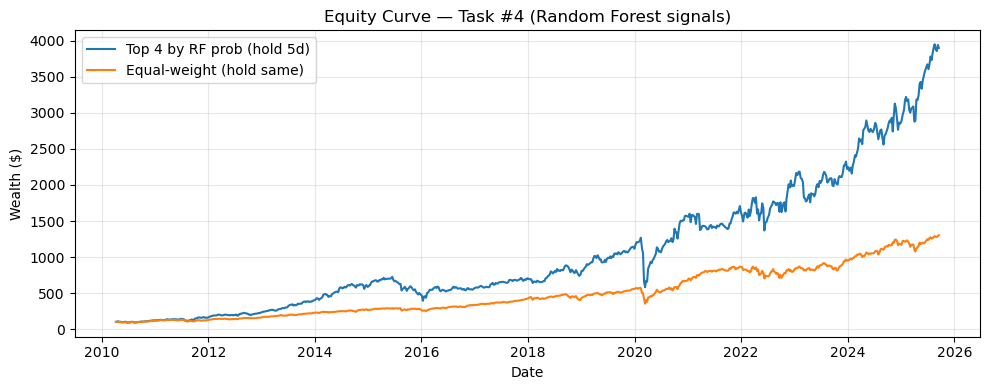

,Mean r_port,Std r_port,Hit rate r_port (>0),Mean r_ew
0,0.005511,0.039112,0.589974,0.003633


In [ ]:
# 4) Plot equity curves
plt.figure(figsize=(10,4))
plt.plot(equity.index, equity['Wealth'], label=f'Top {top_k} by RF prob (hold {horizon}d)')
plt.plot(equity_bench.index, equity_bench['Wealth_EW'], label='Equal-weight (hold same)')
plt.title('Equity Curve — Task #4 (Random Forest signals)')
plt.xlabel('Date'); plt.ylabel('Wealth ($)')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# 5) Quick stats table (per-rebalance period)
stats = pd.DataFrame({
    'Mean r_port': [period_returns['r_port'].mean()],
    'Std  r_port': [period_returns['r_port'].std()],
    'Hit rate r_port (>0)': [(period_returns['r_port'] > 0).mean()],
    'Mean r_ew':   [period_returns['r_ew'].mean()]
})
stats


### Compare your result to 1000 portfolios with random weights (you generate the weights at the beginning of the testing period and you never re-balance your portfolio).

In [84]:
# === Random static-weight portfolios on NON-OVERLAPPING 5d periods ===
np.random.seed(42)
n_portfolios  = 1000
initial_wealth = 100.0
horizon = 5  # must match your RF backtest holding period

# 1) Build the same non-overlapping date grid used by the RF backtest
all_dates  = test_rf['Date'].drop_duplicates().sort_values().to_list()
block_dates = all_dates[::horizon]                           # non-overlapping anchors

# 2) Pivot realized 5d forward returns on those block dates only
pivot_sub = (
    test_rf[test_rf['Date'].isin(block_dates)]
    .pivot_table(index='Date', columns='Ticker', values='Future_Return_5d')
    .fillna(0.0)                                            # no position if missing
    .sort_index()
)
dates = pivot_sub.index
n_assets = pivot_sub.shape[1]

# 3) Generate random static weights (sum to 1)
weights = np.random.dirichlet(np.ones(n_assets), size=n_portfolios)  # (1000, n_assets)
# quick sanity check
sums = weights.sum(axis=1)

# 4) Wealth paths over non-overlapping blocks
R = pivot_sub.to_numpy()                                    # (T, N)
T = len(dates)
wealth_paths = np.zeros((T, n_portfolios))
wealth_paths[0, :] = initial_wealth

for t in range(1, T):
    r_t = (R[t-1, :] @ weights.T)                          # portfolio 5d return in block t-1
    wealth_paths[t, :] = wealth_paths[t-1, :] * (1.0 + r_t)

# 5) Align your RF equity curve to the SAME block dates
rf_equity_block = equity.reindex(dates, method='ffill').iloc[:, 0]


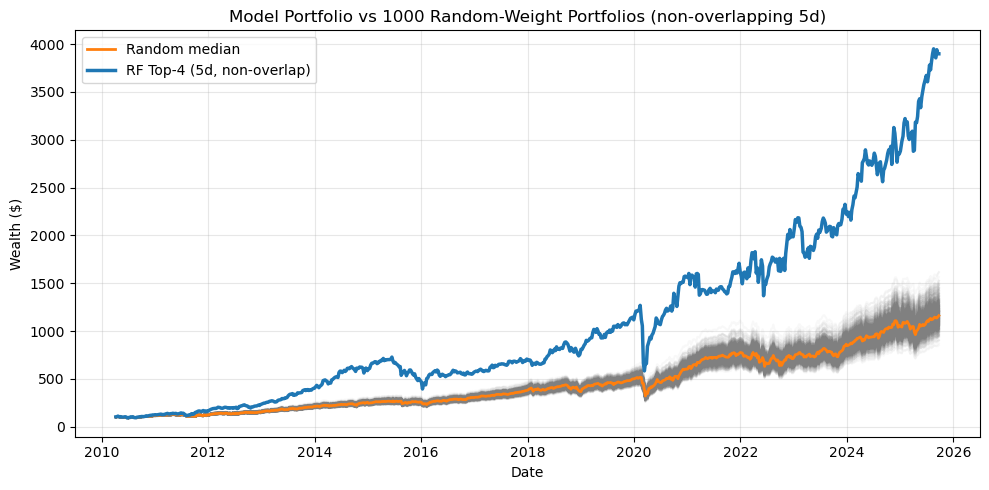

In [85]:
# 6) Plot: random paths (light grey) + RF Top-4 (blue) + median random (orange)
plt.figure(figsize=(10,5))
plt.plot(dates, wealth_paths, color='gray', alpha=0.05)
plt.plot(dates, np.median(wealth_paths, axis=1), color='tab:orange', lw=2, label='Random median')
plt.plot(dates, rf_equity_block, color='tab:blue', lw=2.5, label='RF Top-4 (5d, non-overlap)')
plt.title('Model Portfolio vs 1000 Random-Weight Portfolios (non-overlapping 5d)')
plt.xlabel('Date'); plt.ylabel('Wealth ($)')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

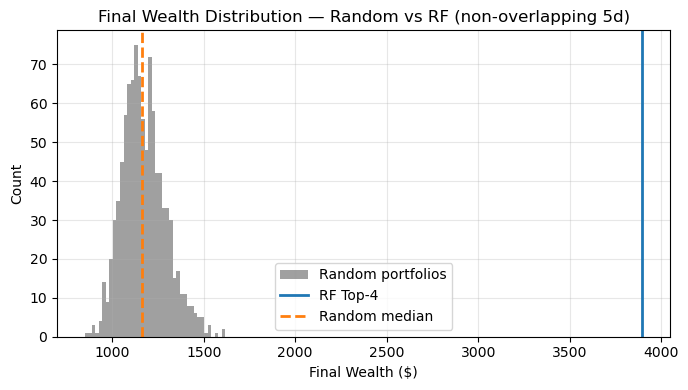

RF final wealth: $3,897.54
Random portfolio median final wealth: $1,160.20
RF outperformed 100.0% of random portfolios.


In [86]:
# 7) Final-wealth comparison
final_wealth_random = wealth_paths[-1, :]
plt.figure(figsize=(7,4))
plt.hist(final_wealth_random, bins=40, color='gray', alpha=0.75, label='Random portfolios')
plt.axvline(rf_equity_block.iloc[-1], color='tab:blue', lw=2, label='RF Top-4')
plt.axvline(np.median(final_wealth_random), color='tab:orange', lw=2, linestyle='--', label='Random median')
plt.title('Final Wealth Distribution — Random vs RF (non-overlapping 5d)')
plt.xlabel('Final Wealth ($)'); plt.ylabel('Count')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

print(f"RF final wealth: ${rf_equity_block.iloc[-1]:,.2f}")
print(f"Random portfolio median final wealth: ${np.median(final_wealth_random):,.2f}")
print(f"RF outperformed {(rf_equity_block.iloc[-1] > final_wealth_random).mean()*100:.1f}% of random portfolios.")


**Interpretation**

The Random Forest strategy achieves a **final wealth more than 3× higher** than the median random-weight portfolio.  
The equity-curve comparison shows that the **RF portfolio consistently stays above** the random distribution (grey fan) and the **median random path** (orange).  
This suggests that even a **weak but systematic predictive edge**—reflected in the RF’s modest **AUC ≈ 0.56**—can generate substantial **cumulative alpha** when reapplied iteratively in short horizons.

The random portfolios cluster tightly around a median wealth near \$1.1k, forming a narrow dispersion typical of buy-and-hold diversification.  
In contrast, the RF model, by actively tilting toward stocks with slightly higher conditional return probabilities, compounds these small relative advantages into a markedly higher terminal value.

### Imagine that you now pay trading fees : 3 bps (basic point) of the amount invested is charged for every transaction, what is the new performance of your AI-driven portfolio?


– You want to sell 50$ of stock A to buy the same amount of stock B, you will be charged 0.015$, so you’ll end up with only 49.985$ invested in stock B.

In [87]:
horizon   = 5
top_k     = 4
fee_rate  = 0.0003    # 3 bps per BUY notional
W0        = 100.0

# ---- non-overlapping anchors (same as before) ----
all_dates   = test_rf['Date'].drop_duplicates().sort_values().to_list()
block_dates = all_dates[::horizon]  # non-overlapping 5d blocks

# For quick lookup of 5d forward return by (date, ticker)
r_lookup = (test_rf
            .set_index(['Date','Ticker'])['Future_Return_5d']
            .sort_index())

# For picking top names each block
def top_picks_at(date, k=top_k):
    df = test_rf[test_rf['Date'] == date]
    if df.empty:
        return []
    return df.nlargest(k, 'ProbaUp')['Ticker'].tolist()

# --- Helper: apply period return to each holding (dollar notional) ---
def evolve_holdings(holdings: dict, date):
    """Update holdings values using 5d return anchored at `date`."""
    new_vals = {}
    for tic, val in holdings.items():
        try:
            r = r_lookup.loc[(date, tic)]
        except KeyError:
            r = 0.0  # if missing return, assume flat for that block
        new_vals[tic] = val * (1.0 + r)
    return new_vals

# --- Helper: rebalance to equal weights among 'picks', paying 3 bps on BUYS only ---
def rebalance_with_fees(curr_holdings: dict, picks: list, wealth: float):
    """
    Target equal weights among `picks`. Compute buy notional relative to current holdings,
    charge fee_rate * buys, then allocate (wealth - fee) equally across picks.
    Returns (new_holdings_dict, fee_paid).
    """
    # Current values for all tickers after evolution
    curr_vals = {tic: curr_holdings.get(tic, 0.0) for tic in set(curr_holdings) | set(picks)}

    # Target equal-weight (pre-fee) in dollars
    target_each = wealth / max(len(picks), 1)

    # Compute BUYS needed to reach pre-fee target
    buys = 0.0
    for tic in picks:
        delta = target_each - curr_vals.get(tic, 0.0)
        if delta > 0:
            buys += delta

    fee = fee_rate * buys
    # After paying fee, scale target down to fit available wealth
    target_each_after_fee = (wealth - fee) / max(len(picks), 1)

    # New equal-weight holdings (post-fee)
    new_holdings = {tic: 0.0 for tic in curr_vals.keys()}  # clear all
    for tic in picks:
        new_holdings[tic] = target_each_after_fee

    return new_holdings, fee


In [88]:
# ---- Walk-forward simulation with fees ----
holdings = {}               # dollar value per ticker
wealth   = W0
equity_fee = []             # (date, wealth_with_fees)
fees_paid = []              # track per-block fees

for i, t in enumerate(block_dates):
    if i == 0:
        # Initial buy: pay fees on full invest into top_k
        picks0 = top_picks_at(t, top_k)
        init_fee = fee_rate * wealth  # buy notional equals W0
        investable = wealth - init_fee
        per_name   = investable / max(len(picks0), 1)
        holdings   = {tic: per_name for tic in picks0}
        wealth     = investable
        equity_fee.append((t, wealth))
        fees_paid.append((t, init_fee))
        continue

    # 1) evolve existing holdings over previous block's returns (anchored at t_prev)
    t_prev  = block_dates[i-1]
    holdings = evolve_holdings(holdings, t_prev)
    wealth   = sum(holdings.values())

    # 2) choose new picks at current block anchor, then rebalance with fees
    picks_t  = top_picks_at(t, top_k)
    holdings, fee_t = rebalance_with_fees(holdings, picks_t, wealth)
    wealth   = sum(holdings.values()) - 0.0  # (rebalance function already sized to wealth - fee)

    equity_fee.append((t, wealth))
    fees_paid.append((t, fee_t))

equity_fee = pd.DataFrame(equity_fee, columns=['Date','Wealth_Fee']).set_index('Date')
fees_paid  = pd.DataFrame(fees_paid,  columns=['Date','Fee']).set_index('Date')
total_fees = fees_paid['Fee'].sum()

print(f"Initial wealth:        ${W0:,.2f}")
print(f"Final wealth (3 bps):  ${equity_fee['Wealth_Fee'].iloc[-1]:,.2f}")
print(f"Total fees paid:       ${total_fees:,.2f}")

Initial wealth:        $100.00
Final wealth (3 bps):  $3,123.68
Total fees paid:       $200.86


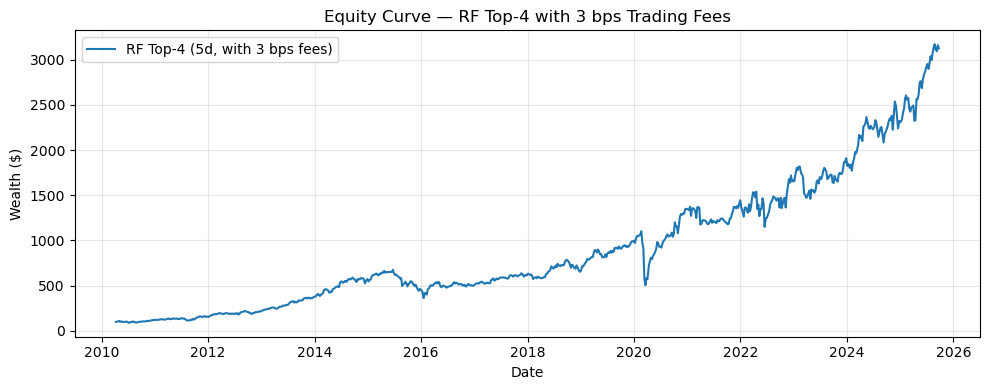

In [ ]:

# --- Plot with-fee equity curve (optionally compare to no-fee 'equity' if you kept it) ---
plt.figure(figsize=(10,4))
plt.plot(equity_fee.index, equity_fee['Wealth_Fee'], label='RF Top-4 (5d, with 3 bps fees)')
# If you still have your no-fee series named `equity`:
# plt.plot(equity.index, equity['Wealth'], label='RF Top-4 (no fees)', alpha=0.7)
plt.title('Equity Curve — RF Top-4 with 3 bps Trading Fees')
plt.xlabel('Date'); plt.ylabel('Wealth ($)')
plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()

In [91]:
# --- Quick summary table per block (optional) ---
summary = pd.DataFrame({
    'Wealth_Fee': equity_fee['Wealth_Fee'],
    'Fee': fees_paid['Fee']
}).assign(Gross_Wealth=lambda d: d['Wealth_Fee'] + d['Fee'])

summary.tail(10)


,Wealth_Fee,Fee,Gross_Wealth
Date,,,
2025-07-22,2954.488694,0.886613,2955.375307
2025-07-29,3036.586653,0.911249,3037.497902
2025-08-05,2995.426689,0.898898,2996.325587
2025-08-12,3067.935558,0.920657,3068.856215
2025-08-19,3128.793010,0.938920,3129.731930
2025-08-26,3169.399196,0.951105,3170.350301
2025-09-03,3114.896724,0.934749,3115.831474
2025-09-10,3091.498999,0.927728,3092.426727
2025-09-17,3159.160325,0.948033,3160.108357
